In [45]:
import pandas as pd

In [46]:
df = pd.read_csv("results/combined_run_details.csv")
df["dataset"] = df["dataset"].replace({"sports2": "sports"})
df.head()

,run_id,dataset,namespace,index_name,user_namespace,embed_model,top_k,combine_strategy,rerank_strategy,update_strategy,...,neutral_question,expected_chunk_id,priming_question_count,baseline_score,post_priming_score,delta,baseline_expected_rank,post_priming_expected_rank,baseline_chunk_ids,post_priming_chunk_ids
0,combined_run,civil,zai,541,users,llama-text-embed-v2,5,query-only,none,none,...,"What role does the foundation or ""loading"" sys...",civil-1,0,6.448459,6.448459,0.0,3.0,3.0,minecraft-1|civil-4|civil-1|civil-6|civil-7,minecraft-1|civil-4|civil-1|civil-6|civil-7
1,combined_run,civil,zai,541,users,llama-text-embed-v2,5,query-only,none,none,...,How do builders ensure that a structure can wi...,civil-4,0,7.626827,7.626827,0.0,2.0,2.0,minecraft-2|civil-4|civil-7|civil-1|civil-5,minecraft-2|civil-4|civil-7|civil-1|civil-5
2,combined_run,civil,zai,541,users,llama-text-embed-v2,5,query-only,none,none,...,Which materials are prioritized when high stre...,civil-2,0,6.017783,6.017783,0.0,3.0,3.0,minecraft-2|civil-3|civil-2|minecraft-5|civil-7,minecraft-2|civil-3|civil-2|minecraft-5|civil-7
3,combined_run,civil,zai,541,users,llama-text-embed-v2,5,query-only,none,none,...,"How is internal stress or ""tension"" managed to...",civil-5,0,11.948459,11.948459,0.0,1.0,1.0,civil-5|civil-7|civil-2|civil-3|civil-1,civil-5|civil-7|civil-2|civil-3|civil-1
4,combined_run,civil,zai,541,users,llama-text-embed-v2,5,query-only,none,none,...,What techniques are used to protect a structur...,civil-10,0,11.948459,11.948459,0.0,1.0,1.0,civil-10|civil-3|civil-7|civil-5|civil-8,civil-10|civil-3|civil-7|civil-5|civil-8


In [47]:
df.value_counts(["dataset", "combine_strategy", "update_strategy", "rerank_strategy", "alpha_mode"])

dataset  combine_strategy  update_strategy  rerank_strategy  alpha_mode
science  linear-comb       none             none             static        270
                           moving-average   none             static        270
                           none             cross-encoder    static        270
                           moving-average   cross-encoder    static        270
         spherical-comb    none             none             static        270
                           moving-average   none             static        270
                           none             cross-encoder    static        270
                           moving-average   cross-encoder    static        270
sports   linear-comb       none             none             static        120
                           moving-average   none             static        120
                           none             cross-encoder    static        120
                           moving-average   cross-encoder  

In [48]:
df[(df["combine_strategy"] == "linear-comb") &
    (df["dataset"] == "science")].value_counts(["rerank_strategy", "update_strategy"])

rerank_strategy  update_strategy
none             none               360
                 moving-average     360
cross-encoder    none               360
                 moving-average     360
Name: count, dtype: int64

In [49]:
df.groupby(["combine_strategy", "rerank_strategy", "alpha_mode"], as_index=False)["post_priming_score"].mean()

,combine_strategy,rerank_strategy,alpha_mode,post_priming_score
0,linear-comb,cross-encoder,sliding,4.402729
1,linear-comb,cross-encoder,static,4.316797
2,linear-comb,none,sliding,4.615812
3,linear-comb,none,static,4.421436
4,query-only,cross-encoder,none,3.462972
5,query-only,none,none,3.471648
6,spherical-comb,cross-encoder,sliding,5.364608
7,spherical-comb,cross-encoder,static,4.357140
8,spherical-comb,none,sliding,5.381933
9,spherical-comb,none,static,4.471318


In [50]:
subset_df = df[
    (
        (df["combine_strategy"] == "linear-comb") &
        (df["rerank_strategy"] == "none") &
        (df["alpha_mode"] == "sliding")
    )
    |
    (
        (df["combine_strategy"] == "spherical-comb") &
        (df["rerank_strategy"] == "none") &
        (df["alpha_mode"] == "sliding")
    )
    |
    (
        (df["combine_strategy"] == "query-only") &
        (df["rerank_strategy"] == "none") &
        (df["alpha_mode"] == "none")
    )
]

In [51]:
subset_df.groupby(["dataset", "combine_strategy"])["post_priming_score"].mean()

dataset  combine_strategy
civil    linear-comb         7.569239
         query-only          6.933148
         spherical-comb      7.623201
science  linear-comb         4.032661
         query-only          2.639809
         spherical-comb      4.671888
sports   linear-comb         4.451187
         query-only          3.612534
         spherical-comb      5.858898
Name: post_priming_score, dtype: float64

,dataset,combine_strategy,post_priming_score_normalized,query_only_normalized,absolute_improvement,percent_improvement
1,civil,query-only,0.5803,0.5803,0.0000,0.0000
0,civil,linear-comb,0.6335,0.5803,0.0532,9.1746
2,civil,spherical-comb,0.6380,0.5803,0.0578,9.9529
4,science,query-only,0.2209,0.2209,0.0000,0.0000
3,science,linear-comb,0.3375,0.2209,0.1166,52.7634
5,science,spherical-comb,0.3910,0.2209,0.1701,76.9783
7,sports,query-only,0.3023,0.3023,0.0000,0.0000
6,sports,linear-comb,0.3725,0.3023,0.0702,23.2151
8,sports,spherical-comb,0.4903,0.3023,0.1880,62.1825


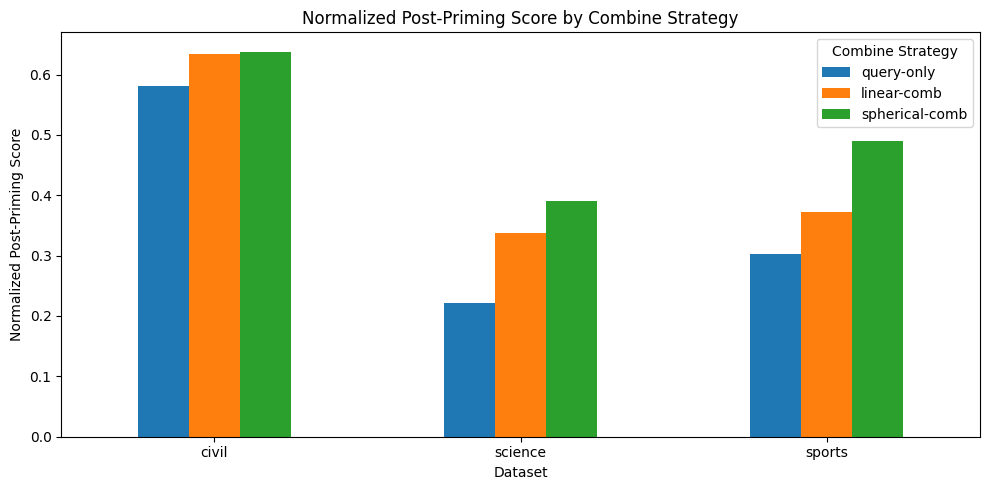

In [52]:
import matplotlib.pyplot as plt

NORMALIZATION_DENOM = 11.948459118879
STRATEGY_ORDER = ["query-only", "linear-comb", "spherical-comb"]

# Work on a copy to avoid chained-assignment issues.
analysis_df = subset_df.copy()
analysis_df["post_priming_score_normalized"] = (
    analysis_df["post_priming_score"] / NORMALIZATION_DENOM
)

# Mean normalized score by dataset and combine strategy.
norm_means = (
    analysis_df
    .groupby(["dataset", "combine_strategy"], as_index=False)["post_priming_score_normalized"]
    .mean()
)

# Build an improvement table relative to query-only within each dataset.
baseline = (
    norm_means[norm_means["combine_strategy"] == "query-only"]
    .rename(columns={"post_priming_score_normalized": "query_only_normalized"})
    [["dataset", "query_only_normalized"]]
)

improvement_table = (
    norm_means.merge(baseline, on="dataset", how="left")
    .assign(
        absolute_improvement=lambda d: (
            d["post_priming_score_normalized"] - d["query_only_normalized"]
        ),
        percent_improvement=lambda d: (
            d["absolute_improvement"] / d["query_only_normalized"] * 100
        ),
    )
)

# Keep table rows in requested strategy order.
improvement_table["combine_strategy"] = pd.Categorical(
    improvement_table["combine_strategy"],
    categories=STRATEGY_ORDER,
    ordered=True,
)
improvement_table = improvement_table.sort_values(["dataset", "combine_strategy"])

display(
    improvement_table[[
        "dataset",
        "combine_strategy",
        "post_priming_score_normalized",
        "query_only_normalized",
        "absolute_improvement",
        "percent_improvement",
    ]].round(4)
)

# Plot 1: normalized post-priming score by strategy (includes baseline).
pivot_norm = (
    norm_means.pivot(
        index="dataset",
        columns="combine_strategy",
        values="post_priming_score_normalized",
    )
    .reindex(columns=STRATEGY_ORDER)
)

ax = pivot_norm.plot(kind="bar", figsize=(10, 5))
ax.set_title("Normalized Post-Priming Score by Combine Strategy")
ax.set_xlabel("Dataset")
ax.set_ylabel("Normalized Post-Priming Score")
plt.xticks(rotation=0)
plt.legend(title="Combine Strategy")
plt.tight_layout()
plt.show()

In [53]:
subset_df2 = df[
    (
        (df["combine_strategy"] == "linear-comb") &
        (df["alpha_mode"] == "sliding")
    )
    |
    (
        (df["combine_strategy"] == "spherical-comb") &
        (df["alpha_mode"] == "sliding")
    )
]

rerank_strategy,none,cross-encoder
dataset,,
civil,0.6335,0.6299
science,0.3375,0.3377
sports,0.3725,0.3071


rerank_strategy,none,cross-encoder
dataset,,
civil,0.6380,0.7017
science,0.3910,0.4100
sports,0.4903,0.4103


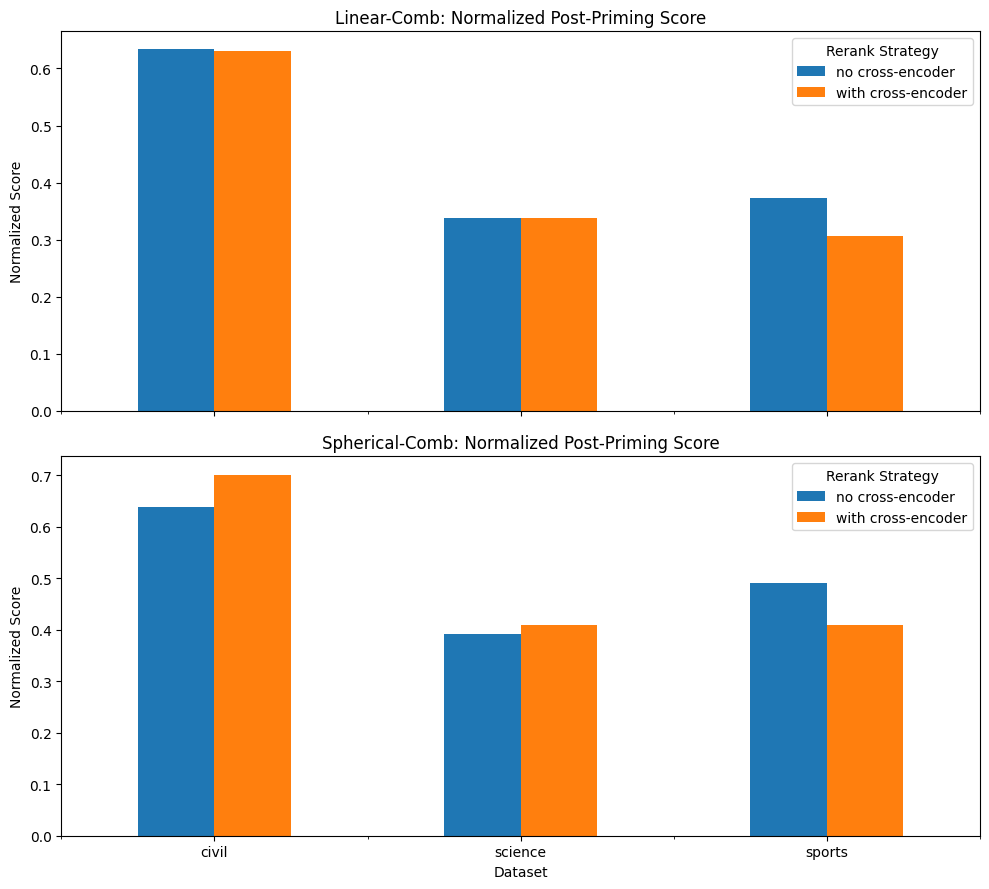

In [55]:
import matplotlib.pyplot as plt

NORMALIZATION_DENOM = 11.948459118879

plot_df2 = subset_df2.copy()
plot_df2["post_priming_score_normalized"] = (
    plot_df2["post_priming_score"] / NORMALIZATION_DENOM
)

agg = (
    plot_df2
    .groupby(["dataset", "combine_strategy", "rerank_strategy"], as_index=False)["post_priming_score_normalized"]
    .mean()
)

linear_pivot = (
    agg[agg["combine_strategy"] == "linear-comb"]
    .pivot(index="dataset", columns="rerank_strategy", values="post_priming_score_normalized")
    .reindex(columns=["none", "cross-encoder"])
)

spherical_pivot = (
    agg[agg["combine_strategy"] == "spherical-comb"]
    .pivot(index="dataset", columns="rerank_strategy", values="post_priming_score_normalized")
    .reindex(columns=["none", "cross-encoder"])
)

# Optional: keep tables for exact values.
display(linear_pivot.round(4))
display(spherical_pivot.round(4))

# Single figure with two vertically stacked subplots.
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 9), sharex=True)

linear_pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("Linear-Comb: Normalized Post-Priming Score")
axes[0].set_ylabel("Normalized Score")
axes[0].legend(["no cross-encoder", "with cross-encoder"], title="Rerank Strategy")
axes[0].tick_params(axis="x", rotation=0)

spherical_pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Spherical-Comb: Normalized Post-Priming Score")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Normalized Score")
axes[1].legend(["no cross-encoder", "with cross-encoder"], title="Rerank Strategy")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [59]:
subset_df3 = df[
    (
        (df["combine_strategy"] == "linear-comb")
    )
    |
    (
        (df["combine_strategy"] == "spherical-comb")
    )
]

alpha_setting,0.5,0.8,0.95,sliding
dataset,,,,
civil,0.6698,0.6280,0.5900,0.6508
science,0.4005,0.2991,0.2377,0.3691
sports,0.4503,0.3400,0.2917,0.3951


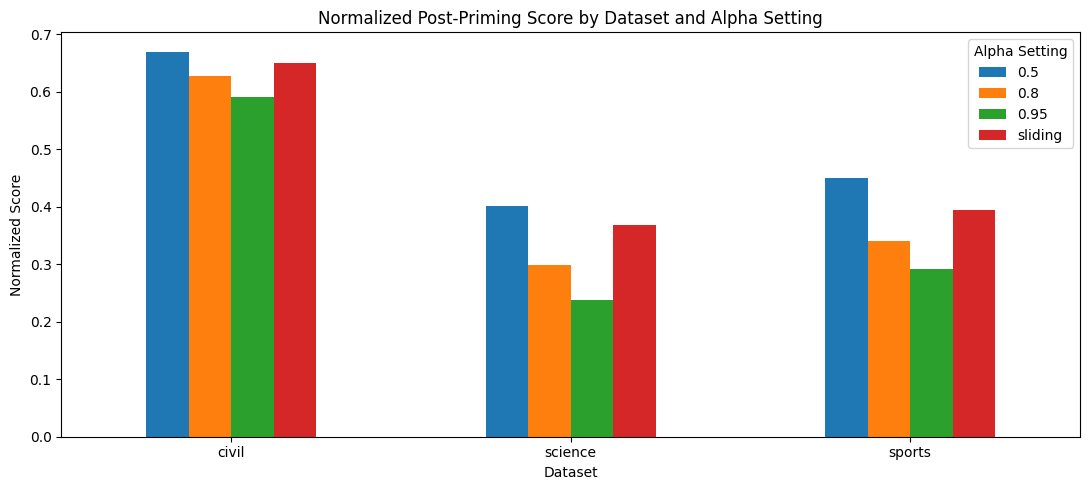

In [60]:
import matplotlib.pyplot as plt

NORMALIZATION_DENOM = 11.948459118879

plot_df3 = subset_df3.copy()
plot_df3["post_priming_score_normalized"] = (
    plot_df3["post_priming_score"] / NORMALIZATION_DENOM
)

# Build one plotting label that supports both fixed alpha values and sliding mode.
plot_df3["alpha_setting"] = plot_df3["alpha_value"].astype(str)
plot_df3.loc[plot_df3["alpha_mode"] == "sliding", "alpha_setting"] = "sliding"

alpha_means = (
    plot_df3
    .groupby(["dataset", "alpha_setting"], as_index=False)["post_priming_score_normalized"]
    .mean()
)

# Order numeric alpha bars ascending, then include sliding at the end if present.
numeric_settings = sorted(
    [s for s in alpha_means["alpha_setting"].unique() if s != "sliding"],
    key=float,
)
ordered_settings = numeric_settings + (["sliding"] if "sliding" in alpha_means["alpha_setting"].unique() else [])

pivot_alpha = (
    alpha_means
    .pivot(index="dataset", columns="alpha_setting", values="post_priming_score_normalized")
    .reindex(columns=ordered_settings)
)

display(pivot_alpha.round(4))

ax = pivot_alpha.plot(kind="bar", figsize=(11, 5))
ax.set_title("Normalized Post-Priming Score by Dataset and Alpha Setting")
ax.set_xlabel("Dataset")
ax.set_ylabel("Normalized Score")
plt.xticks(rotation=0)
plt.legend(title="Alpha Setting")
plt.tight_layout()
plt.show()